# Analysis of Student Learning Behavior and Academic Performance

## Project Overview

This project analyzes student learning behavior and academic performance using a Kaggle dataset containing approximately 14,000 student records and 16 attributes.

The analysis focuses on exploring relationships between students' learning habits, engagement, resources, motivation, stress levels, and academic performance.

### Objectives

- Understand and prepare the student performance dataset
- Analyze student learning and behavioral patterns
- Investigate relationships between learning factors and exam performance
- Identify factors showing meaningful relationships with academic performance
- Present findings using statistical analysis and visualizations

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
pd.set_option('display.max_columns', None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/sadhikmohammedaiman/student-performance-and-learning-behavior-dataset/student_performance.csv


In [3]:
file_path = "/kaggle/input/datasets/sadhikmohammedaiman/student-performance-and-learning-behavior-dataset/student_performance.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully.
Rows: 14003
Columns: 16


In [4]:
df.head()

,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade
0,19,64,1,0,0,1,0,19,2,8,1,59,40,0,1,3
1,19,64,1,0,0,1,0,23,3,16,0,90,66,0,1,2
2,19,64,1,0,0,1,0,28,1,19,0,67,99,1,1,0
3,19,64,1,1,0,1,0,19,2,8,1,59,40,0,1,3
4,19,64,1,1,0,1,0,23,3,16,0,90,66,0,1,2


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14003 entries, 0 to 14002
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   StudyHours            14003 non-null  int64
 1   Attendance            14003 non-null  int64
 2   Resources             14003 non-null  int64
 3   Extracurricular       14003 non-null  int64
 4   Motivation            14003 non-null  int64
 5   Internet              14003 non-null  int64
 6   Gender                14003 non-null  int64
 7   Age                   14003 non-null  int64
 8   LearningStyle         14003 non-null  int64
 9   OnlineCourses         14003 non-null  int64
 10  Discussions           14003 non-null  int64
 11  AssignmentCompletion  14003 non-null  int64
 12  ExamScore             14003 non-null  int64
 13  EduTech               14003 non-null  int64
 14  StressLevel           14003 non-null  int64
 15  FinalGrade            14003 non-null  int64
dtypes: i

In [6]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
StudyHours              0
Attendance              0
Resources               0
Extracurricular         0
Motivation              0
Internet                0
Gender                  0
Age                     0
LearningStyle           0
OnlineCourses           0
Discussions             0
AssignmentCompletion    0
ExamScore               0
EduTech                 0
StressLevel             0
FinalGrade              0
dtype: int64


In [7]:
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 1534


In [8]:
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 1534


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
StudyHours,14003.0,19.987431,5.890637,5.0,16.0,20.0,24.0,44.0
Attendance,14003.0,80.194316,11.472181,60.0,70.0,80.0,90.0,100.0
Resources,14003.0,1.104406,0.697362,0.0,1.0,1.0,2.0,2.0
Extracurricular,14003.0,0.594158,0.491072,0.0,0.0,1.0,1.0,1.0
Motivation,14003.0,0.905806,0.695896,0.0,0.0,1.0,1.0,2.0
Internet,14003.0,0.925516,0.262566,0.0,1.0,1.0,1.0,1.0
Gender,14003.0,0.551953,0.497311,0.0,0.0,1.0,1.0,1.0
Age,14003.0,23.532172,3.514293,18.0,20.0,24.0,27.0,29.0
LearningStyle,14003.0,1.515461,1.112941,0.0,1.0,2.0,3.0,3.0
OnlineCourses,14003.0,9.891952,6.112801,0.0,5.0,10.0,15.0,20.0


In [10]:
df['FinalGrade'].value_counts().sort_index()

FinalGrade
0    3832
1    3310
2    3618
3    3243
Name: count, dtype: int64

# 5. Data Cleaning

The dataset was examined for missing values and duplicate records.

No missing values were identified. However, duplicate records were found and will be removed to prevent repeated observations from influencing the analysis.

The original dataset contains 14,003 records. After removing exact duplicate records, the remaining observations will be used for the analysis.

In [11]:
df_clean = df.drop_duplicates().copy()

print(f"Original number of records: {len(df)}")
print(f"Number of duplicate records removed: {df.duplicated().sum()}")
print(f"Number of records after cleaning: {len(df_clean)}")

Original number of records: 14003
Number of duplicate records removed: 1534
Number of records after cleaning: 12469


In [12]:

print(f"Remaining duplicate records: {df_clean.duplicated().sum()}")
print(f"Missing values: {df_clean.isnull().sum().sum()}")

Remaining duplicate records: 0
Missing values: 0


In [54]:
df_clean.to_csv(
    '/kaggle/working/student_performance_cleaned.csv',
    index=False
)

print("Cleaned dataset saved successfully.")
print("Final dataset shape:", df_clean.shape)

Cleaned dataset saved successfully.
Final dataset shape: (12469, 16)


# 6. Descriptive Analysis

Descriptive statistics are used to summarize the main characteristics of the cleaned dataset. Measures such as mean, standard deviation, minimum, maximum, and quartiles are examined to understand the distribution and range of the variables.

In [13]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
StudyHours,12469.0,20.034405,6.049485,5.0,16.0,20.0,24.0,44.0
Attendance,12469.0,80.239233,11.469028,60.0,70.0,80.0,90.0,100.0
Resources,12469.0,1.101371,0.711171,0.0,1.0,1.0,2.0,2.0
Extracurricular,12469.0,0.583126,0.493061,0.0,0.0,1.0,1.0,1.0
Motivation,12469.0,0.907370,0.709599,0.0,0.0,1.0,1.0,2.0
Internet,12469.0,0.917074,0.275781,0.0,1.0,1.0,1.0,1.0
Gender,12469.0,0.538616,0.498527,0.0,0.0,1.0,1.0,1.0
Age,12469.0,23.529152,3.510956,18.0,20.0,24.0,27.0,29.0
LearningStyle,12469.0,1.515358,1.116071,0.0,1.0,2.0,3.0,3.0
OnlineCourses,12469.0,9.872404,6.114025,0.0,5.0,10.0,15.0,20.0


In [14]:
exam_stats = df_clean['ExamScore'].describe()

print(exam_stats)

count    12469.000000
mean        70.310691
std         17.696639
min         40.000000
25%         55.000000
50%         70.000000
75%         86.000000
max        100.000000
Name: ExamScore, dtype: float64


## 6.1 Distribution of Exam Scores

The distribution of exam scores is visualized to understand the overall performance pattern of students in the dataset.

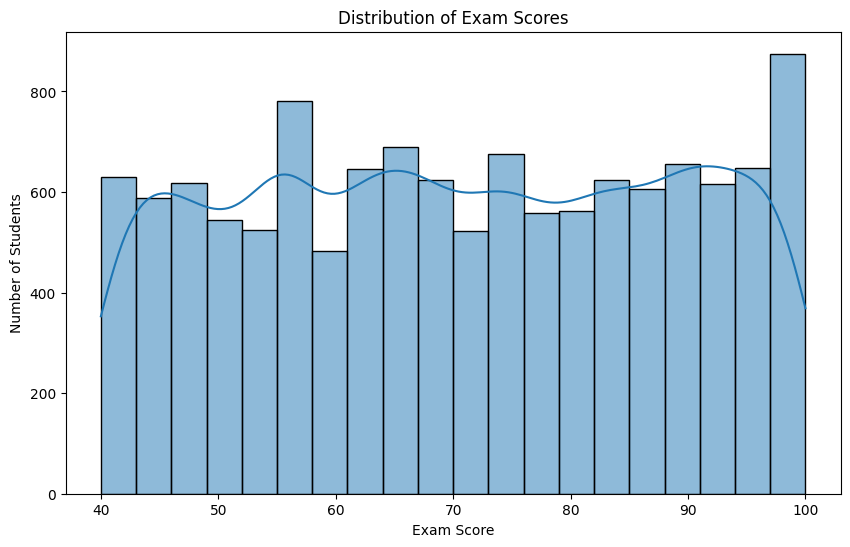

In [15]:
plt.figure(figsize=(10, 6))

sns.histplot(df_clean['ExamScore'], bins=20, kde=True)

plt.title('Distribution of Exam Scores')
plt.xlabel('Exam Score')
plt.ylabel('Number of Students')

plt.show()

In [16]:


mean_exam_score = df_clean['ExamScore'].mean()

print(f"Average Exam Score: {mean_exam_score:.2f}")

Average Exam Score: 70.31


## 6.2 Study Hours and Exam Score

This analysis examines whether students who report different amounts of study time tend to have different exam scores. A scatter plot is used to visualize the relationship between study hours and exam performance.

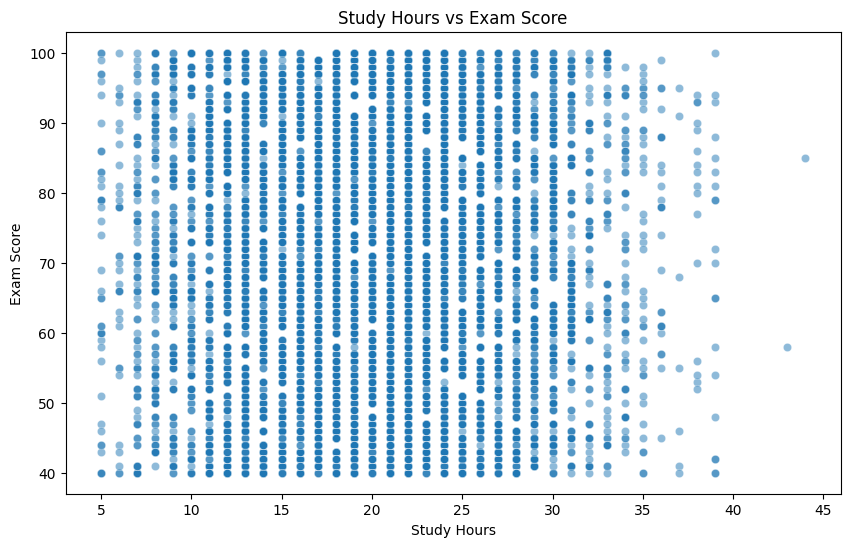

In [17]:


plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x='StudyHours',
    y='ExamScore',
    alpha=0.5
)

plt.title('Study Hours vs Exam Score')
plt.xlabel('Study Hours')
plt.ylabel('Exam Score')

plt.show()

In [18]:


correlation, p_value = stats.pearsonr(
    df_clean['StudyHours'],
    df_clean['ExamScore']
)

print(f"Pearson correlation: {correlation:.4f}")
print(f"P-value: {p_value:.4f}")

Pearson correlation: 0.0042
P-value: 0.6390


### Interpretation

The scatter plot shows a wide spread of exam scores across different study-hour levels. The Pearson correlation is 0.0042, indicating an extremely weak positive linear relationship between study hours and exam scores.

The p-value is 0.6390, which is greater than the 0.05 significance level. Therefore, there is no statistically significant linear relationship between study hours and exam scores in this dataset.

## 6.3 Attendance and Exam Score

This analysis examines whether attendance is associated with students' exam performance. A scatter plot and Pearson correlation are used to assess the strength and statistical significance of the relationship.

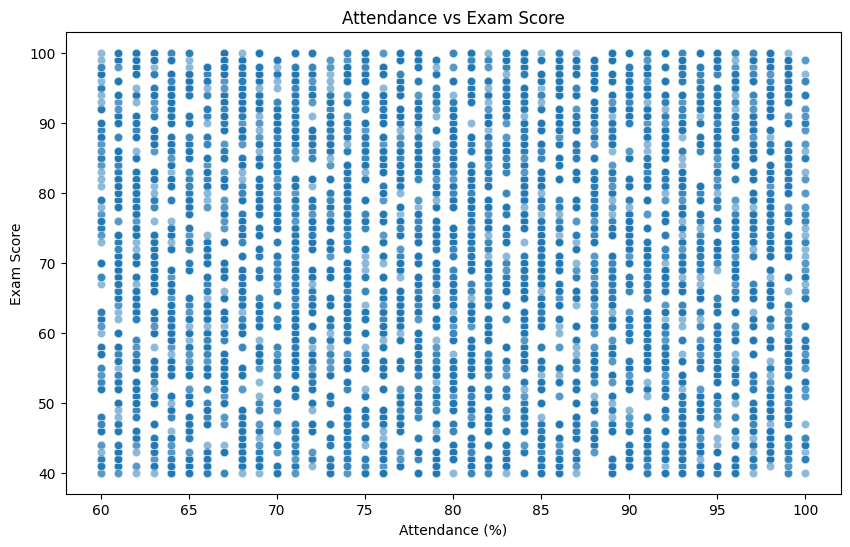

In [19]:

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x='Attendance',
    y='ExamScore',
    alpha=0.5
)

plt.title('Attendance vs Exam Score')
plt.xlabel('Attendance (%)')
plt.ylabel('Exam Score')
plt.show()

In [20]:


correlation, p_value = stats.pearsonr(
    df_clean['Attendance'],
    df_clean['ExamScore']
)

print(f"Pearson correlation: {correlation:.4f}")
print(f"P-value: {p_value:.4f}")

Pearson correlation: -0.0142
P-value: 0.1140


### Interpretation

The scatter plot shows a wide distribution of exam scores across different attendance levels. The Pearson correlation is -0.0142, indicating an extremely weak negative linear relationship between attendance and exam scores.

The p-value is 0.1140, which is greater than the 0.05 significance level. Therefore, there is no statistically significant linear relationship between attendance and exam scores in this dataset.

## 6.4 Assignment Completion and Exam Score

This analysis examines whether assignment completion is associated with students' exam performance. A scatter plot and Pearson correlation are used to assess the relationship.

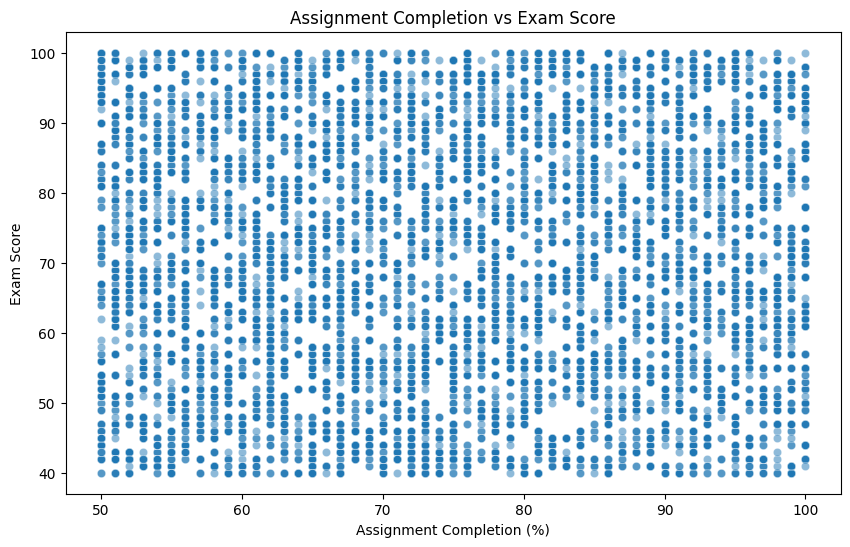

In [21]:


plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x='AssignmentCompletion',
    y='ExamScore',
    alpha=0.5
)

plt.title('Assignment Completion vs Exam Score')
plt.xlabel('Assignment Completion (%)')
plt.ylabel('Exam Score')

plt.show()

In [22]:

correlation, p_value = stats.pearsonr(
    df_clean['AssignmentCompletion'],
    df_clean['ExamScore']
)

print(f"Pearson correlation: {correlation:.4f}")
print(f"P-value: {p_value:.4f}")

Pearson correlation: 0.0274
P-value: 0.0022


### Interpretation

The scatter plot shows a wide distribution of exam scores across different assignment-completion levels. The Pearson correlation is 0.0274, indicating a very weak positive linear relationship between assignment completion and exam scores.

The p-value is 0.0022, which is below the 0.05 significance level. Therefore, the relationship is statistically significant. However, the correlation coefficient is extremely close to zero, indicating that the strength of the relationship is negligible in practical terms.

This result demonstrates that statistical significance alone does not imply a strong or practically meaningful relationship, particularly in a large dataset.

## 6.5 Motivation and Exam Score

This analysis compares exam scores across different motivation levels. Boxplots and group-level descriptive statistics are used to examine whether students in different motivation groups show differences in academic performance.

In [23]:

motivation_stats = df_clean.groupby('Motivation')['ExamScore'].agg(
    ['count', 'mean', 'median', 'std']
)

motivation_stats

,count,mean,median,std
Motivation,,,,
0,3770,70.223607,70.0,17.593645
1,6084,70.509698,71.0,17.773145
2,2615,69.973231,69.0,17.666901


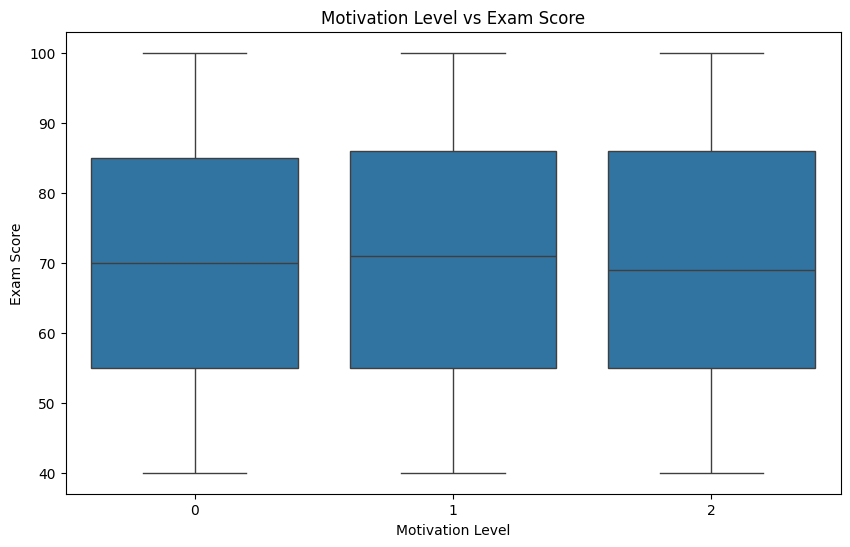

In [24]:


plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    x='Motivation',
    y='ExamScore'
)

plt.title('Motivation Level vs Exam Score')
plt.xlabel('Motivation Level')
plt.ylabel('Exam Score')

plt.show()


In [25]:


motivation_groups = [
    group['ExamScore'].values
    for _, group in df_clean.groupby('Motivation')
]

f_stat, p_value = stats.f_oneway(*motivation_groups)

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4f}")

F-statistic: 0.9058
P-value: 0.4043


### Interpretation

The boxplot shows substantial overlap in exam scores across the different motivation levels. The one-way ANOVA produced an F-statistic of 0.9058 and a p-value of 0.4043.

Since the p-value is greater than the 0.05 significance level, there is no statistically significant difference in mean exam scores between the motivation groups in this dataset.

## 6.6 Stress Level and Exam Score

This analysis compares exam scores across different stress levels. Group-level descriptive statistics, a boxplot, and one-way ANOVA are used to examine whether exam performance differs significantly between stress groups.

In [26]:

stress_stats = df_clean.groupby('StressLevel')['ExamScore'].agg(
    ['count', 'mean', 'median', 'std']
)

stress_stats

,count,mean,median,std
StressLevel,,,,
0,2524,71.896593,73.0,17.508324
1,3614,69.741561,69.0,17.833972
2,6331,70.003317,70.0,17.659134


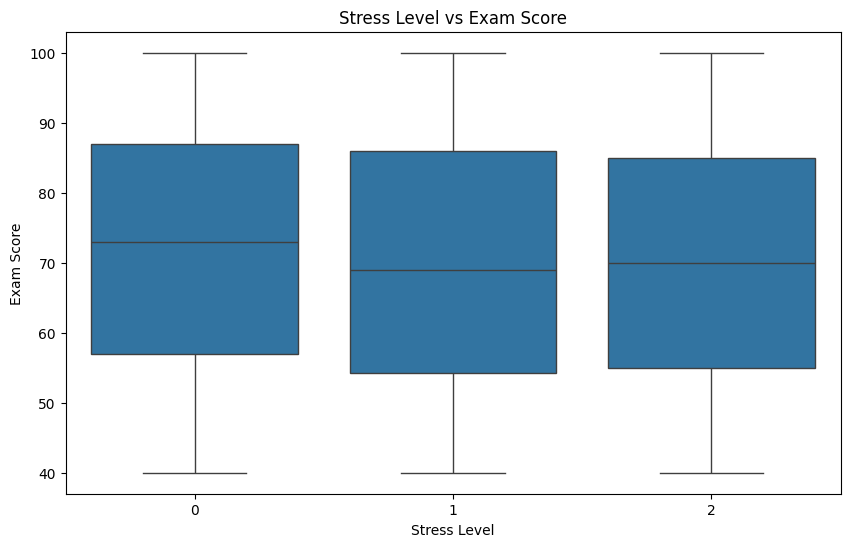

In [27]:


plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    x='StressLevel',
    y='ExamScore'
)

plt.title('Stress Level vs Exam Score')
plt.xlabel('Stress Level')
plt.ylabel('Exam Score')

plt.show()

In [28]:

stress_groups = [
    group['ExamScore'].values
    for _, group in df_clean.groupby('StressLevel')
]

f_stat, p_value = stats.f_oneway(*stress_groups)

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4f}")

F-statistic: 12.9840
P-value: 0.0000


### Interpretation

The boxplot shows differences in the distribution of exam scores across the stress-level groups. The one-way ANOVA produced an F-statistic of 12.9840 with a p-value below 0.001.

Since the p-value is below the 0.05 significance level, there is a statistically significant difference in mean exam scores between at least some of the stress-level groups.

A post-hoc comparison would be required to determine which specific stress-level groups differ significantly.

# 7. Correlation Analysis

Correlation analysis is used to examine the strength and direction of linear relationships between the variables in the dataset and exam performance.

Pearson correlation coefficients range from -1 to +1. Values close to zero indicate weak linear relationships, while values closer to -1 or +1 indicate stronger negative or positive relationships.

In [29]:


correlations = df_clean.corr(numeric_only=True)['ExamScore'].sort_values(
    ascending=False
)

correlations

ExamScore               1.000000
AssignmentCompletion    0.027402
OnlineCourses           0.020684
Gender                  0.016750
EduTech                 0.010311
LearningStyle           0.008282
Resources               0.005119
StudyHours              0.004201
Motivation             -0.003539
Extracurricular        -0.006821
Internet               -0.007342
Age                    -0.010137
Attendance             -0.014156
Discussions            -0.031209
StressLevel            -0.034324
FinalGrade             -0.968365
Name: ExamScore, dtype: float64

## 7.1 Correlation Heatmap

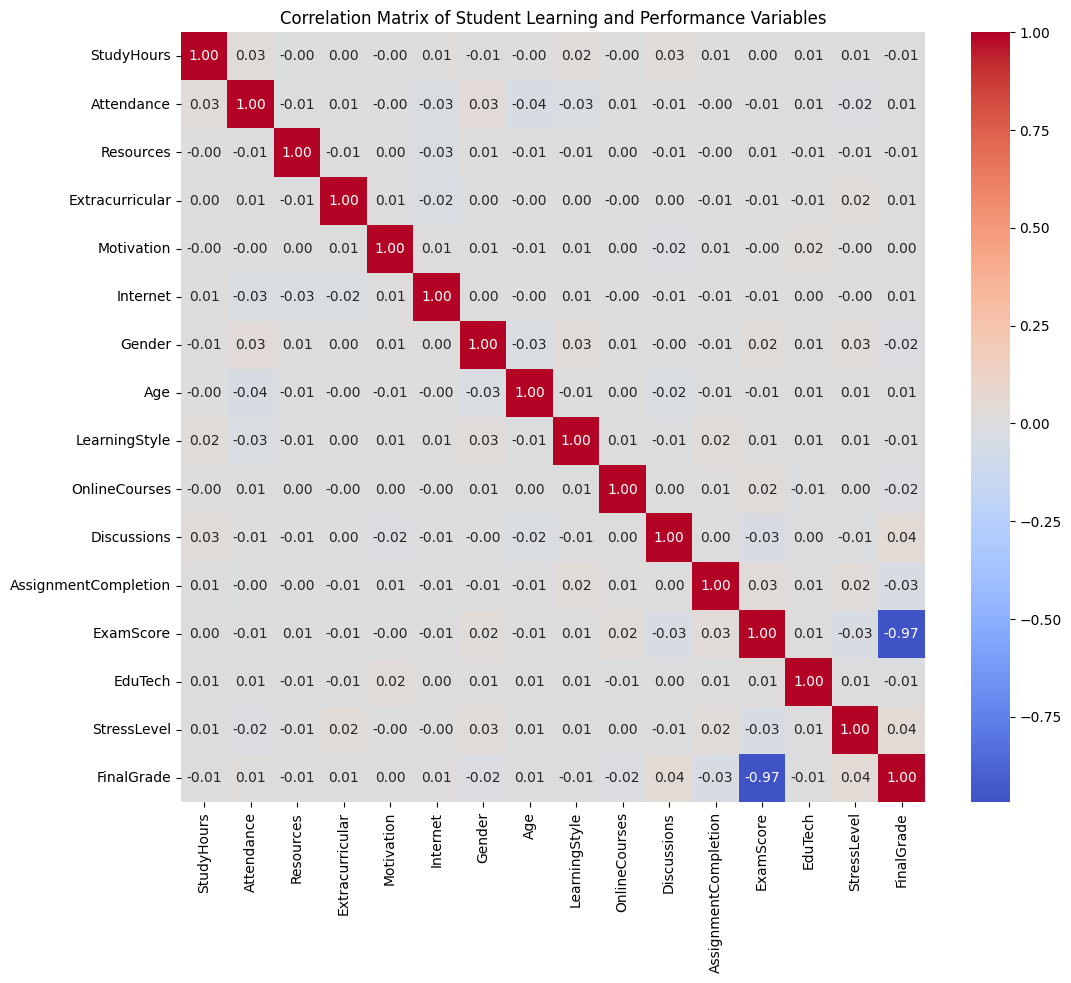

In [30]:
# Correlation heatmap

plt.figure(figsize=(12, 10))

correlation_matrix = df_clean.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix of Student Learning and Performance Variables')
plt.show()

In [31]:
# Rank learning and behavioral variables by their correlation with ExamScore

exclude_columns = ['ExamScore', 'FinalGrade']

correlation_results = (
    df_clean.drop(columns=exclude_columns)
    .corrwith(df_clean['ExamScore'])
    .sort_values(key=abs, ascending=False)
)

correlation_results

StressLevel            -0.034324
Discussions            -0.031209
AssignmentCompletion    0.027402
OnlineCourses           0.020684
Gender                  0.016750
Attendance             -0.014156
EduTech                 0.010311
Age                    -0.010137
LearningStyle           0.008282
Internet               -0.007342
Extracurricular        -0.006821
Resources               0.005119
StudyHours              0.004201
Motivation             -0.003539
dtype: float64

## 7.2 Correlation of Learning and Behavioral Factors with Exam Score

The correlations between exam scores and the learning and behavioral variables are compared to identify which factors show the strongest linear relationships with academic performance.

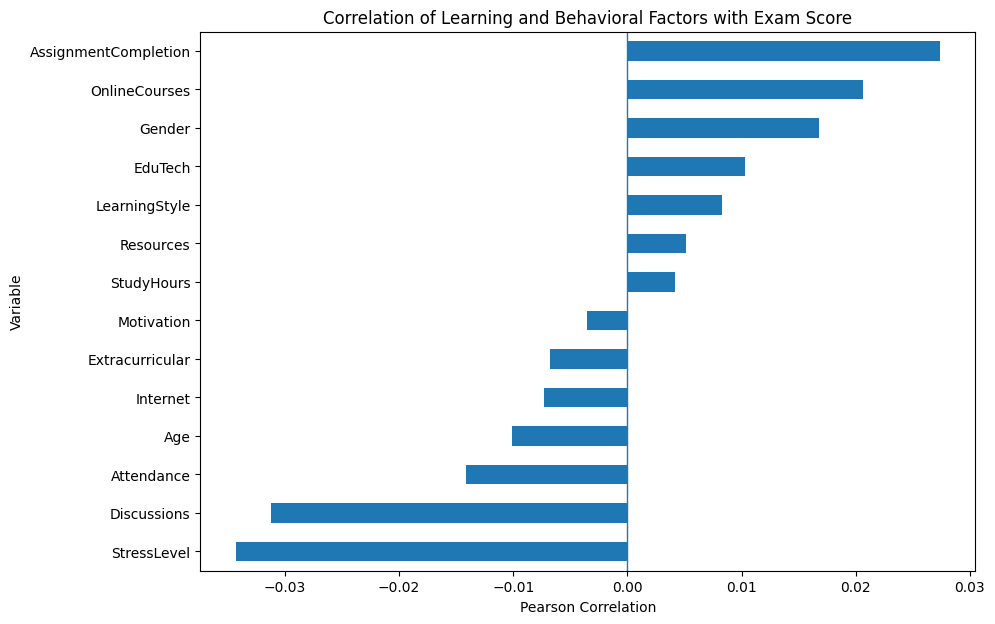

In [32]:


plt.figure(figsize=(10, 7))

correlation_results.sort_values().plot(kind='barh')

plt.title('Correlation of Learning and Behavioral Factors with Exam Score')
plt.xlabel('Pearson Correlation')
plt.ylabel('Variable')

plt.axvline(0, linewidth=1)

plt.show()

In [34]:

results = []

variables = [
    'StudyHours',
    'Attendance',
    'Resources',
    'Extracurricular',
    'Motivation',
    'Internet',
    'Gender',
    'Age',
    'LearningStyle',
    'OnlineCourses',
    'Discussions',
    'AssignmentCompletion',
    'EduTech',
    'StressLevel'
]

for variable in variables:
    r, p = stats.pearsonr(
        df_clean[variable],
        df_clean['ExamScore']
    )
    
    results.append({
        'Variable': variable,
        'Correlation': r,
        'P_Value': p
    })

correlation_table = pd.DataFrame(results)

correlation_table['Absolute_Correlation'] = (
    correlation_table['Correlation'].abs()
)

correlation_table.sort_values(
    'Absolute_Correlation',
    ascending=False
)

,Variable,Correlation,P_Value,Absolute_Correlation
13,StressLevel,-0.034324,0.000126,0.034324
10,Discussions,-0.031209,0.000491,0.031209
11,AssignmentCompletion,0.027402,0.002212,0.027402
9,OnlineCourses,0.020684,0.020904,0.020684
6,Gender,0.016750,0.061442,0.016750
1,Attendance,-0.014156,0.113955,0.014156
12,EduTech,0.010311,0.249598,0.010311
7,Age,-0.010137,0.257682,0.010137
8,LearningStyle,0.008282,0.355095,0.008282
5,Internet,-0.007342,0.412353,0.007342


## 7.3 Detailed Analysis of Stress Level

Stress level showed the strongest linear association with exam scores among the examined learning and behavioral variables. A one-way ANOVA also indicated statistically significant differences between stress groups.

Further analysis is performed to determine the magnitude of the group differences and which specific groups differ from each other.

In [35]:

stress_summary = df_clean.groupby('StressLevel')['ExamScore'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
)

stress_summary

,count,mean,median,std,min,max
StressLevel,,,,,,
0,2524,71.896593,73.0,17.508324,40,100
1,3614,69.741561,69.0,17.833972,40,100
2,6331,70.003317,70.0,17.659134,40,100


In [36]:

grand_mean = df_clean['ExamScore'].mean()

between_group_ss = sum(
    len(group) * (group['ExamScore'].mean() - grand_mean) ** 2
    for _, group in df_clean.groupby('StressLevel')
)

total_ss = sum(
    (df_clean['ExamScore'] - grand_mean) ** 2
)

eta_squared = between_group_ss / total_ss

print(f"Eta-squared: {eta_squared:.4f}")

Eta-squared: 0.0021


In [37]:

from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey_result = pairwise_tukeyhsd(
    endog=df_clean['ExamScore'],
    groups=df_clean['StressLevel'],
    alpha=0.05
)

print(tukey_result)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     0      1   -2.155    0.0   -3.23   -1.08   True
     0      2  -1.8933    0.0 -2.8688 -0.9177   True
     1      2   0.2618 0.7575 -0.6022  1.1257  False
----------------------------------------------------


### Interpretation

The one-way ANOVA identified a statistically significant difference in exam scores across stress-level groups (F = 12.9840, p < 0.001).

The Tukey HSD post-hoc test showed statistically significant differences between Stress Level 0 and Stress Level 1, and between Stress Level 0 and Stress Level 2. However, the difference between Stress Level 1 and Stress Level 2 was not statistically significant.

The eta-squared effect size was 0.0021, indicating that stress-level group membership explains only a very small proportion of the variation in exam scores.

Therefore, although differences between some stress groups are statistically significant, the practical effect of stress level on exam-score variation is small in this dataset.

## 7.4 Discussions and Exam Score

This analysis examines whether participation in discussions is associated with students' exam performance. Group-level statistics and a comparison of exam scores are used to investigate the relationship.

In [38]:


discussion_stats = df_clean.groupby('Discussions')['ExamScore'].agg(
    ['count', 'mean', 'median', 'std']
)

discussion_stats

,count,mean,median,std
Discussions,,,,
0,4910,70.995927,71.0,17.768686
1,7559,69.865591,69.0,17.636600


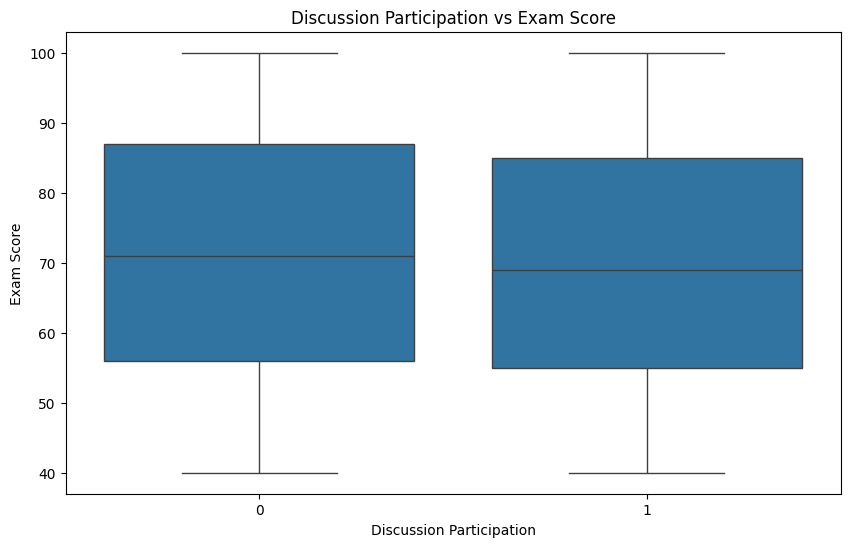

In [39]:

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    x='Discussions',
    y='ExamScore'
)

plt.title('Discussion Participation vs Exam Score')
plt.xlabel('Discussion Participation')
plt.ylabel('Exam Score')

plt.show()

In [40]:


correlation, p_value = stats.pearsonr(
    df_clean['Discussions'],
    df_clean['ExamScore']
)

print(f"Pearson correlation: {correlation:.4f}")
print(f"P-value: {p_value:.4f}")

Pearson correlation: -0.0312
P-value: 0.0005


### Interpretation

The Pearson correlation between discussion participation and exam score is -0.0312 with a p-value of 0.0005.

The p-value indicates that the relationship is statistically significant at the 5% significance level. However, the correlation coefficient is very close to zero, indicating an extremely weak negative linear relationship.

Therefore, discussion participation shows statistical significance in this dataset, but its practical relationship with exam performance is negligible.

# 8. Overall Statistical Analysis

This section summarizes the relationships between student learning and behavioral variables and exam performance.

Pearson correlation coefficients are used to measure the strength and direction of linear relationships. Statistical significance is considered together with the magnitude of the correlation to distinguish statistically significant relationships from practically meaningful relationships.

FinalGrade is excluded from the predictor analysis because it is directly related to the ExamScore variable.

In [41]:
# Calculate correlations between selected variables and ExamScore

variables = [
    'StudyHours',
    'Attendance',
    'Resources',
    'Extracurricular',
    'Motivation',
    'Internet',
    'Gender',
    'Age',
    'LearningStyle',
    'OnlineCourses',
    'Discussions',
    'AssignmentCompletion',
    'EduTech',
    'StressLevel'
]

results = []

for variable in variables:
    correlation, p_value = stats.pearsonr(
        df_clean[variable],
        df_clean['ExamScore']
    )
    
    results.append({
        'Variable': variable,
        'Correlation': correlation,
        'P_Value': p_value,
        'Absolute_Correlation': abs(correlation)
    })

correlation_summary = pd.DataFrame(results)

correlation_summary = correlation_summary.sort_values(
    'Absolute_Correlation',
    ascending=False
)

correlation_summary

,Variable,Correlation,P_Value,Absolute_Correlation
13,StressLevel,-0.034324,0.000126,0.034324
10,Discussions,-0.031209,0.000491,0.031209
11,AssignmentCompletion,0.027402,0.002212,0.027402
9,OnlineCourses,0.020684,0.020904,0.020684
6,Gender,0.016750,0.061442,0.016750
1,Attendance,-0.014156,0.113955,0.014156
12,EduTech,0.010311,0.249598,0.010311
7,Age,-0.010137,0.257682,0.010137
8,LearningStyle,0.008282,0.355095,0.008282
5,Internet,-0.007342,0.412353,0.007342


### Overall Interpretation

The correlation analysis shows that none of the investigated learning and behavioral variables has a strong linear relationship with exam performance.

Stress level has the strongest absolute correlation with ExamScore (r = -0.0343), followed by discussion participation (r = -0.0312) and assignment completion (r = 0.0274). However, all correlation coefficients are very close to zero, indicating negligible linear relationships.

Some variables have statistically significant p-values, which is partly influenced by the large sample size. Therefore, statistical significance alone is not considered sufficient evidence of a practically meaningful relationship. Both the correlation magnitude and p-value are considered when interpreting the results.

Overall, the analysis suggests that simple linear relationships between individual behavioral variables and exam performance are very weak in this dataset.

# 9. Statistical Testing

Statistical tests are used to determine whether differences in exam performance between student groups are statistically meaningful.

Based on the exploratory analysis, stress level is examined further using a one-way ANOVA test. This test evaluates whether the mean ExamScore differs significantly across the three stress-level groups.

If the ANOVA result is statistically significant, Tukey's HSD post-hoc test is used to identify which specific groups differ from each other.

In [42]:
stress_summary = df_clean.groupby('StressLevel')['ExamScore'].agg(
    ['count', 'mean', 'median', 'std']
).round(2)

stress_summary

,count,mean,median,std
StressLevel,,,,
0,2524,71.90,73.0,17.51
1,3614,69.74,69.0,17.83
2,6331,70.00,70.0,17.66


In [43]:
stress_groups = [
    group['ExamScore'].values
    for _, group in df_clean.groupby('StressLevel')
]

f_stat, p_value = stats.f_oneway(*stress_groups)

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.6f}")

F-statistic: 12.9840
P-value: 0.000002


### ANOVA Interpretation

The one-way ANOVA produced an F-statistic of 12.9840 with a p-value below 0.001. Therefore, the null hypothesis that all three stress-level groups have the same mean exam score is rejected at the 5% significance level.

This indicates that there is a statistically significant difference in ExamScore among at least some of the stress-level groups.

However, ANOVA does not identify which groups differ from each other. Therefore, Tukey's HSD post-hoc test is used for pairwise comparisons.

### Tukey HSD Interpretation

The Tukey HSD post-hoc test shows significant differences between StressLevel 0 and StressLevel 1, as well as between StressLevel 0 and StressLevel 2.

However, the difference between StressLevel 1 and StressLevel 2 is not statistically significant.

This suggests that the lowest stress-level group differs in exam performance from both other groups, while the two higher stress-level groups have relatively similar exam performance.

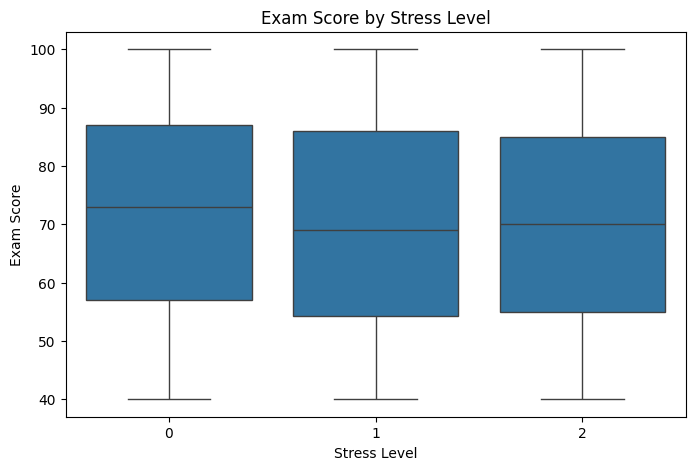

In [44]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x='StressLevel',
    y='ExamScore'
)

plt.title('Exam Score by Stress Level')
plt.xlabel('Stress Level')
plt.ylabel('Exam Score')

plt.show()

6. Descriptive Analysis
   6.1 Distribution of Exam Scores
   6.2 Study Hours and Exam Score
   6.3 Attendance and Exam Score
   6.4 Assignment Completion and Exam Score
   6.5 Motivation and Exam Score
   6.6 Stress Level and Exam Score

7. Correlation Analysis
   7.1 Correlation Matrix
   7.2 Correlation Summary

9. Statistical Testing
   9.1 Stress Level ANOVA
   9.2 Tukey HSD Post-hoc Test

### 9.3 Motivation Level and Exam Score

A one-way ANOVA is used to examine whether the mean exam scores differ across the three motivation-level groups.

The null hypothesis states that the mean ExamScore is equal across all motivation levels. The alternative hypothesis is that at least one group has a different mean.

In [47]:
motivation_summary = df_clean.groupby('Motivation')['ExamScore'].agg(
    ['count', 'mean', 'median', 'std']
).round(2)

motivation_summary

,count,mean,median,std
Motivation,,,,
0,3770,70.22,70.0,17.59
1,6084,70.51,71.0,17.77
2,2615,69.97,69.0,17.67


In [48]:
motivation_groups = [
    group['ExamScore'].values
    for _, group in df_clean.groupby('Motivation')
]

f_stat, p_value = stats.f_oneway(*motivation_groups)

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.6f}")

F-statistic: 0.9058
P-value: 0.404256


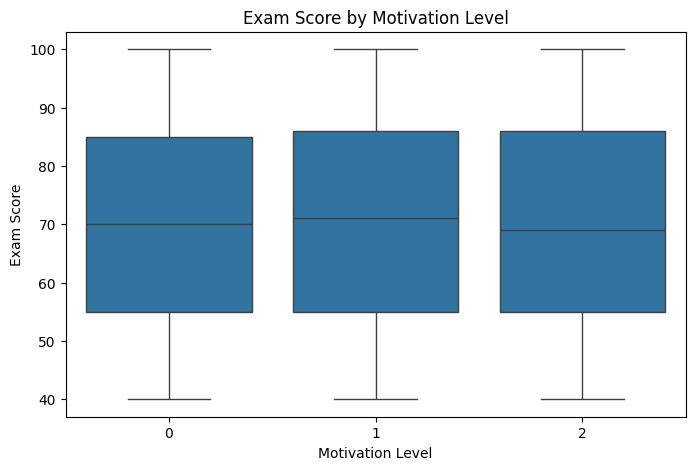

In [49]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x='Motivation',
    y='ExamScore'
)

plt.title('Exam Score by Motivation Level')
plt.xlabel('Motivation Level')
plt.ylabel('Exam Score')

plt.show()

## 10. Multiple Linear Regression

Multiple linear regression is used to examine whether the learning and behavioral variables collectively explain variation in students' exam scores.

ExamScore is used as the dependent variable. FinalGrade is excluded because it is directly derived from ExamScore and would therefore introduce data leakage.

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

features = [
    'StudyHours',
    'Attendance',
    'Resources',
    'Extracurricular',
    'Motivation',
    'Internet',
    'Gender',
    'Age',
    'LearningStyle',
    'OnlineCourses',
    'Discussions',
    'AssignmentCompletion',
    'EduTech',
    'StressLevel'
]

X = df_clean[features]
y = df_clean['ExamScore']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.2f}")

R² Score: 0.0060
RMSE: 17.69


In [51]:
coefficients = pd.DataFrame({
    'Variable': features,
    'Coefficient': model.coef_
})

coefficients['Absolute_Coefficient'] = coefficients['Coefficient'].abs()

coefficients = coefficients.sort_values(
    'Absolute_Coefficient',
    ascending=False
)

coefficients

,Variable,Coefficient,Absolute_Coefficient
10,Discussions,-1.018584,1.018584
5,Internet,-0.672747,0.672747
13,StressLevel,-0.638486,0.638486
6,Gender,0.580391,0.580391
12,EduTech,0.143594,0.143594
4,Motivation,-0.084443,0.084443
8,LearningStyle,0.081705,0.081705
3,Extracurricular,0.073414,0.073414
2,Resources,0.072641,0.072641
7,Age,-0.065134,0.065134


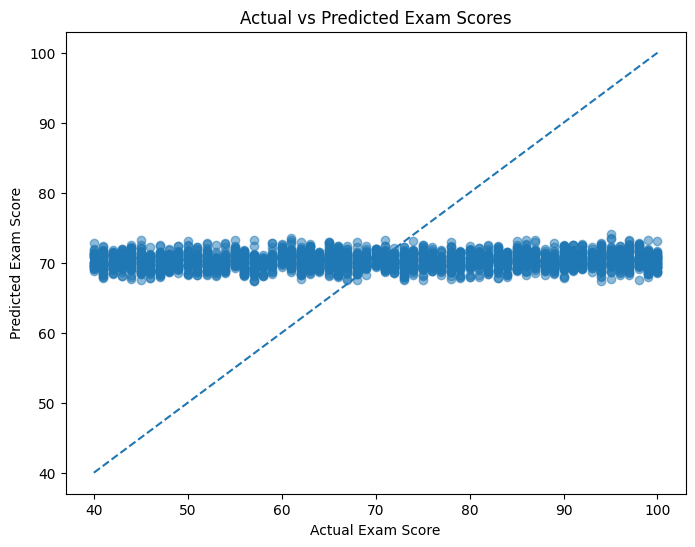

In [52]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel('Actual Exam Score')
plt.ylabel('Predicted Exam Score')
plt.title('Actual vs Predicted Exam Scores')

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.show()

### 10.1 Regression Interpretation

The regression results are evaluated using the R² score and RMSE. The R² score indicates how much variation in exam scores is explained collectively by the selected learning and behavioral variables, while RMSE represents the typical prediction error in exam-score units.

## 10. Key Findings

The analysis of student learning behavior and academic performance produced the following key findings:

- **Study Hours:** Study hours showed almost no linear relationship with exam scores (Pearson correlation = 0.0042, p = 0.6390).

- **Attendance:** Attendance also showed a very weak relationship with exam scores (Pearson correlation = -0.0142, p = 0.1140).

- **Assignment Completion:** Assignment completion had a very small positive correlation with exam scores (r = 0.0274, p = 0.0022). Although statistically significant, the effect is extremely small.

- **Motivation:** Exam scores did not differ significantly across motivation levels based on the ANOVA test (p = 0.4043).

- **Stress Level:** Exam scores differed significantly across stress-level groups (ANOVA p < 0.001). The subsequent Tukey HSD test indicated significant differences between stress groups 0 and 1, and between groups 0 and 2, while the difference between groups 1 and 2 was not statistically significant.

- **Discussion Participation:** Discussion participation showed a very weak negative correlation with exam scores (r = -0.0312, p < 0.001). Despite statistical significance, the magnitude of the relationship is very small.

- **Overall Relationship:** Most learning and behavioral variables showed very weak linear relationships with exam performance.

- **Regression Model:** The multiple linear regression model achieved an R² of 0.0060, indicating that the selected variables explain approximately 0.6% of the variation in exam scores.

Overall, the results suggest that the variables examined in this dataset do not individually or collectively provide strong linear explanations of exam performance. Statistical significance for some variables should therefore be distinguished from practical significance, since the observed effect sizes are very small.

## 11. Conclusion

This project analyzed student learning behavior and its relationship with academic performance using a dataset of student learning and engagement characteristics.

The analysis found that most of the examined variables had very weak linear relationships with exam scores. Study hours and attendance, for example, showed almost no linear association with ExamScore. Assignment completion and discussion participation were statistically significant due to the large sample size, but their effect sizes were extremely small.

Motivation levels did not show statistically significant differences in exam scores. In contrast, stress levels showed statistically significant differences between groups, suggesting that stress was one of the more notable variables identified in the analysis. However, the differences should not be interpreted as evidence of causation.

The multiple linear regression model produced an R² of 0.0060, indicating that the selected variables collectively explained only a very small proportion of the variation in exam scores.

Overall, the results demonstrate the importance of examining both statistical significance and practical effect size when analyzing educational data. The findings also suggest that academic performance in this dataset cannot be adequately explained through simple linear relationships with the selected behavioral variables.

## 12. Limitations

- The dataset is a synthetic representation of student learning behavior and should not be treated as direct evidence of real-world student populations.
- The analysis identifies associations rather than causal relationships.
- Most variables show weak linear relationships with ExamScore, so other factors not included in the dataset may contribute to academic performance.
- Some variables are encoded numerically, and their numerical values should not automatically be interpreted as continuous measurements.
- FinalGrade was excluded from the predictive analysis because it is directly related to ExamScore and could introduce data leakage.